# Tech Challenge I - Saúde da Mulher - Analisando dados para predição do diagnóstico de SOP(Síndrome do Ovário Policístico)
### A Base de dados utilizada, foi sugerida no documento do Tech Challenge e está disponível aqui https://www.kaggle.com/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos.

O passo inicial para trabalhar com a base de dados é carregá-la e realizar uma primeira etapa de limpeza, removendo colunas sem informações úteis e verificando a existência de dados ausentes ou inválidos.

In [119]:
#bibliotecas para análise exploratória dos dados
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#bibliotecas para treinamento do modelo
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [120]:
def dataLoadNPreProcessing():
    data = pd.read_excel("dataset/PCOS_data_without_infertility.xlsx", sheet_name="Full_new")
    #existe uma coluna que não tem dado algum no dataset, então ela é préviamente dropada
    data.drop(columns=["Unnamed: 44"], inplace=True)
    #as colunas que representam identificadores de pacientes não representam qualquer valores úteis para o trabalho então também serão dropadas
    data.drop(columns=["Sl. No"], inplace=True)
    data.drop(columns=["Patient File No."], inplace=True)
    print("\tQuais colunas possuem dados inválidos (NULL ou NaN)")
    column_names = data.columns
    for column in column_names:    
        null_sum = data[column].isnull().sum()
        if null_sum > 0:
            print("\tColuna", column, "total de dados Nulos:",null_sum)
            #droando as linhas que possuem dados nulos
            data.dropna(subset=[column], inplace=True)

    return data

data = dataLoadNPreProcessing()
data.head()

	Quais colunas possuem dados inválidos (NULL ou NaN)
	Coluna Marraige Status (Yrs) total de dados Nulos: 1
	Coluna Fast food (Y/N) total de dados Nulos: 1


,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.0,29.674945,13,72,20,12.00,2,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.0,20.060954,11,72,18,10.00,2,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


Como segunda etapa da exploração dos dados, buscamos identificar as principais correlações entre as variáveis. Para isso, utilizamos o método corr() da biblioteca Pandas que, por padrão, utiliza a correlação de Pearson. Essa medida estatística indica a direção e a intensidade da associação linear entre duas variáveis. Seu coeficiente varia entre -1 e 1: valores próximos de 1 indicam uma forte associação linear positiva, enquanto valores próximos de -1 indicam uma forte associação linear negativa. Valores próximos de zero indicam pouca ou nenhuma associação linear. É importante ressaltar que a existência de correlação não implica uma relação de causalidade entre as variáveis.

In [121]:
#Análise Exploratória de dados
def greaterCorrelations(df, limit=20):
    corr = df.corr(numeric_only=True)

    
    mask = np.triu(
        np.ones(corr.shape),
        k=1
    ).astype(bool)

    corrs = corr.where(mask).stack()

    
    indices = corrs.abs().sort_values(
        ascending=False
    ).index

    resultado = corrs.loc[indices].head(limit)

    return resultado

greaterCorrelations(data)


FSH(mIU/mL)           FSH/LH                   0.971956
Weight (Kg)           BMI                      0.901719
Hip(inch)             Waist(inch)              0.873700
Follicle No. (L)      Follicle No. (R)         0.803633
 Age (yrs)            Marraige Status (Yrs)    0.661834
PCOS (Y/N)            Follicle No. (R)         0.651032
Weight (Kg)           Waist(inch)              0.639154
                      Hip(inch)                0.633911
BMI                   Waist(inch)              0.607394
PCOS (Y/N)            Follicle No. (L)         0.601445
BMI                   Hip(inch)                0.596729
Avg. F size (L) (mm)  Avg. F size (R) (mm)     0.521079
PCOS (Y/N)            Skin darkening (Y/N)     0.481768
                      hair growth(Y/N)         0.466930
BMI                   Weight gain(Y/N)         0.455324
PCOS (Y/N)            Weight gain(Y/N)         0.443652
Weight (Kg)           Weight gain(Y/N)         0.420057
                      Height(Cm)               0

Mesmo que a análise anterior permita identificar relações fortes entre quaisquer variáveis do conjunto de dados, nosso objetivo no projeto é investigar características associadas à presença de SOP. Dessa forma, é necessário analisar especificamente as correlações entre cada variável e a variável-alvo armazenada na coluna "PCOS (Y/N)".

In [122]:
def correlationsWithTarget(df, target):
    corr = df.corr(numeric_only=True)

    result = (
        corr[target]
        .drop(target)
        .sort_values(
            key=abs,
            ascending=False
        )
    )

    return result

correlationsWithTarget(data,"PCOS (Y/N)")

Follicle No. (R)          0.651032
Follicle No. (L)          0.601445
Skin darkening (Y/N)      0.481768
hair growth(Y/N)          0.466930
Weight gain(Y/N)          0.443652
Cycle(R/I)                0.402312
Fast food (Y/N)           0.381772
Pimples(Y/N)              0.288609
Weight (Kg)               0.210280
BMI                       0.198638
Cycle length(days)       -0.183781
Hair loss(Y/N)            0.177458
 Age (yrs)               -0.172436
Waist(inch)               0.162143
Hip(inch)                 0.161700
Avg. F size (L) (mm)      0.129181
Marraige Status (Yrs)    -0.113701
Endometrium (mm)          0.109132
Avg. F size (R) (mm)      0.094268
Pulse rate(bpm)           0.092437
Hb(g/dl)                  0.086934
Vit D3 (ng/mL)            0.085829
Reg.Exercise(Y/N)         0.069481
Height(Cm)                0.066361
LH(mIU/mL)                0.064136
No. of aborptions        -0.056741
RBS(mg/dl)                0.049420
PRG(ng/mL)               -0.043771
RR (breaths/min)    

Dando sequência à análise exploratória, utilizamos representações gráficas para facilitar a observação dos padrões encontrados nos dados. Inicialmente, analisamos a distribuição da variável-alvo PCOS (Y/N), verificando a proporção de pacientes com e sem diagnóstico de SOP. Essa análise é importante para compreender o balanceamento das classes antes do treinamento dos modelos e, posteriormente, interpretar adequadamente suas métricas de desempenho.

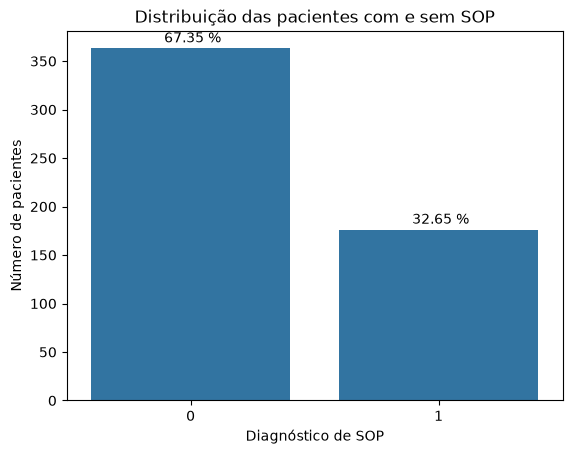

In [123]:
 #normalizando a contagem de valores para a exibição no gráfico
percentual_data = data["PCOS (Y/N)"].value_counts(normalize=True) * 100
    
bars = sns.countplot(data=data, x="PCOS (Y/N)")
for container in bars.containers:    
    bars.bar_label(container, labels=[f"{percentual_data[0] : .2f} %", f"{percentual_data[1] : .2f} %"], padding=2)
    plt.title("Distribuição das pacientes com e sem SOP")
    plt.xlabel("Diagnóstico de SOP")
    plt.ylabel("Número de pacientes")
    plt.show()

O gráfico mostra que aproximadamente 67% das pacientes não apresentam diagnóstico de SOP, enquanto cerca de 33% apresentam. Dessa forma, a base possui um desbalanceamento moderado entre as classes, aproximadamente na proporção de 2:1. Essa característica deverá ser considerada posteriormente na avaliação dos modelos, principalmente para evitar que a acurácia seja utilizada isoladamente como indicador de desempenho.

O próximo item analisado, com base nas relações identificadas anteriormente, é o número de folículos presentes nos ovários esquerdo e direito. Para essa análise utilizamos gráficos do tipo boxplot, que permitem visualizar a mediana, os quartis, a dispersão dos dados e possíveis valores discrepantes (outliers). Dessa forma, podemos comparar a distribuição do número de folículos entre pacientes com e sem diagnóstico de SOP.

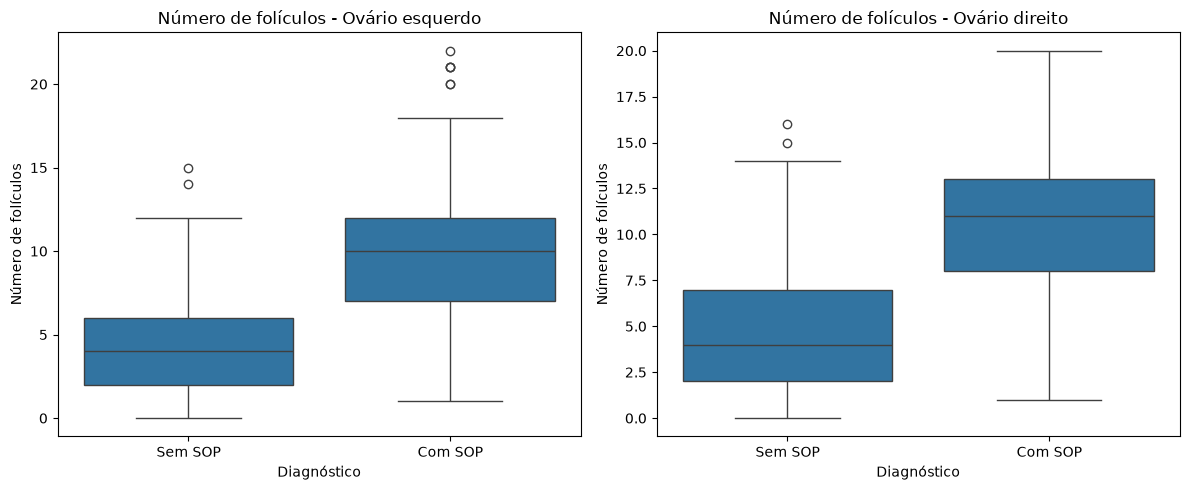

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=data,
    x="PCOS (Y/N)",
    y="Follicle No. (L)",
    ax=axes[0]
)

axes[0].set_title("Número de folículos - Ovário esquerdo")
axes[0].set_xlabel("Diagnóstico")
axes[0].set_ylabel("Número de folículos")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Sem SOP", "Com SOP"])

sns.boxplot(
    data=data,
    x="PCOS (Y/N)",
    y="Follicle No. (R)",
    ax=axes[1]
)

axes[1].set_title("Número de folículos - Ovário direito")
axes[1].set_xlabel("Diagnóstico")
axes[1].set_ylabel("Número de folículos")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Sem SOP", "Com SOP"])

plt.tight_layout()
plt.show()

Os gráficos apresentam uma diferença clara entre os grupos. As pacientes diagnosticadas com SOP apresentam, de maneira geral, maior número de folículos em ambos os ovários. As medianas do grupo com SOP são consideravelmente superiores às observadas no grupo sem diagnóstico, resultado coerente com as correlações positivas encontradas anteriormente para o número de folículos dos ovários direito (\(r=0,651\)) e esquerdo (\(r=0,601\)). Apesar dessa diferença, existe sobreposição entre as distribuições, portanto o número de folículos isoladamente não determina o diagnóstico. Novamente, os resultados indicam associação, e não causalidade.

Dando sequência a nossa análise, podemos analisar alguns sintomas clínicos e a relação deles com o diagnóstico ou não de SOP. Lembrando que a presença destes sintomas não significam que o paciente possui SOP, mas sim que geralmente o paciente que apresenta o diagnóstico possui essas características.

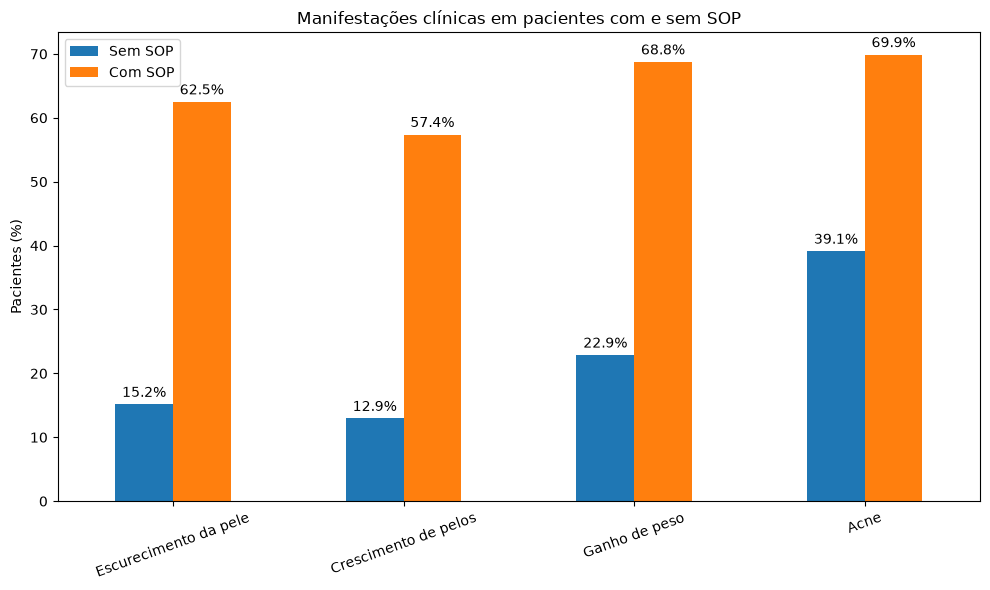

In [125]:
features = [
    "Skin darkening (Y/N)",
    "hair growth(Y/N)",
    "Weight gain(Y/N)",
    "Pimples(Y/N)"
]

labels = {
    "Skin darkening (Y/N)": "Escurecimento da pele",
    "hair growth(Y/N)": "Crescimento de pelos",
    "Weight gain(Y/N)": "Ganho de peso",
    "Pimples(Y/N)": "Acne"
}

resultado = []

for feature in features:

    sem_sop = (
        data[data["PCOS (Y/N)"] == 0][feature].mean()
        * 100
    )

    com_sop = (
        data[data["PCOS (Y/N)"] == 1][feature].mean()
        * 100
    )

    resultado.append({
        "Característica": labels[feature],
        "Sem SOP": sem_sop,
        "Com SOP": com_sop
    })

clinical = pd.DataFrame(resultado)

ax = clinical.set_index("Característica").plot(
    kind="bar",
    figsize=(10, 6)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.title("Manifestações clínicas em pacientes com e sem SOP")
plt.xlabel("")
plt.ylabel("Pacientes (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

O gráfico apresenta diferenças expressivas na frequência das manifestações clínicas entre os dois grupos. Entre as pacientes diagnosticadas com SOP, 62,5% apresentam escurecimento da pele, 57,4% crescimento de pelos, 68,8% ganho de peso e 69,9% acne. Em todos os casos, os percentuais são superiores aos encontrados no grupo sem SOP. Entretanto, essa análise considera cada característica isoladamente e não controla outros fatores que também podem influenciar essas manifestações, como idade, alimentação ou outras condições clínicas. Portanto, os resultados demonstram associação com o diagnóstico de SOP, e não uma relação de causalidade.

De acordo com as pesquisas que realizei sobre a SOP, verifiquei que um dos sintomas mais fortes associados à sua presença é a alteração na duração e regularidade do ciclo menstrual. Devido a falta de documentação do dataset em relação a coluna "Cycle(R/I)", que representa se o ciclo menstrual é regular ou irregular, realizei uma análise de relação entre os valores da coluna "Cycle(R/I)" (2 e 4) e os dados da coluna "Cycle length(days)",  para tentar correlacionar os a duração do ciclo com o identificador.

In [126]:
grupo_2 = data.loc[
    data["Cycle(R/I)"] == 2,
    "Cycle length(days)"
]

grupo_4 = data.loc[
    data["Cycle(R/I)"] == 4,
    "Cycle length(days)"
]

print("Código 2")
print(f"Média:   {grupo_2.mean():.2f}")
print(f"Mediana: {grupo_2.median():.2f}")
print(f"Desvio:  {grupo_2.std():.2f}")
print()

print("Código 4")
print(f"Média:   {grupo_4.mean():.2f}")
print(f"Mediana: {grupo_4.median():.2f}")
print(f"Desvio:  {grupo_4.std():.2f}")

Código 2
Média:   5.13
Mediana: 5.00
Desvio:  0.58

Código 4
Média:   4.42
Mediana: 4.00
Desvio:  2.62


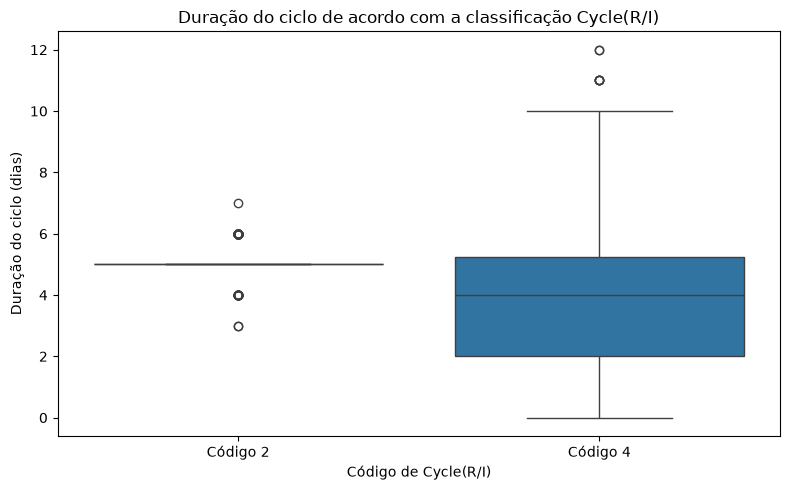

In [127]:
cycle_labels = {
    2: "Código 2",
    4: "Código 4"
}

cycle_analysis = data[
    ["Cycle(R/I)", "Cycle length(days)"]
].copy()

cycle_analysis["Cycle"] = (
    cycle_analysis["Cycle(R/I)"]
    .map(cycle_labels)
)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=cycle_analysis,
    x="Cycle",
    y="Cycle length(days)"
)

plt.title(
    "Duração do ciclo de acordo com a classificação Cycle(R/I)"
)

plt.xlabel("Código de Cycle(R/I)")
plt.ylabel("Duração do ciclo (dias)")

plt.tight_layout()
plt.show()

A análise apresenta uma diferença bastante clara entre os dois códigos. Os registros classificados como código 2 possuem duração de ciclo muito mais concentrada, com mediana de 5 dias e desvio-padrão de aproximadamente 0,58. Já os registros classificados como código 4 apresentam maior dispersão, com desvio-padrão de aproximadamente 2,62. Esses resultados fornecem forte evidência compatível com a interpretação de que o código 2 representa ciclos regulares e o código 4 ciclos irregulares. Entretanto, devido à ausência de documentação da variável no conjunto de dados, essa interpretação deve ser considerada uma inferência baseada nos próprios dados.

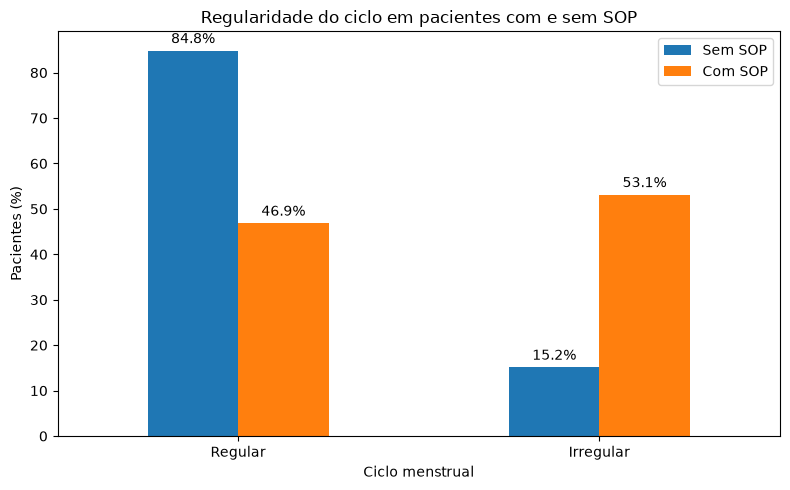

In [128]:
cycle_data = data.copy()

cycle_data["Cycle"] = cycle_data["Cycle(R/I)"].map({
    2: "Regular",
    4: "Irregular"
})

cycle_table = pd.crosstab(
    cycle_data["Cycle"],
    cycle_data["PCOS (Y/N)"],
    normalize="columns"
) * 100

cycle_table.columns = [
    "Sem SOP",
    "Com SOP"
]

# Garantir uma ordem lógica no gráfico
cycle_table = cycle_table.reindex([
    "Regular",
    "Irregular"
])

ax = cycle_table.plot(
    kind="bar",
    figsize=(8, 5)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.title("Regularidade do ciclo em pacientes com e sem SOP")
plt.xlabel("Ciclo menstrual")
plt.ylabel("Pacientes (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

O gráfico mostra uma diferença importante na distribuição da regularidade do ciclo entre os grupos. Entre as pacientes sem diagnóstico de SOP, 84,8% apresentam ciclo classificado como regular e apenas 15,2% como irregular. Já entre as pacientes diagnosticadas com SOP, 53,1% apresentam ciclo irregular e 46,9% ciclo regular. Portanto, a irregularidade do ciclo aparece com frequência consideravelmente maior entre as pacientes com SOP. Entretanto, como aproximadamente 47% das pacientes diagnosticadas ainda apresentam ciclo regular, essa característica isoladamente não é suficiente para determinar o diagnóstico.

A próxima relação de dados que será analisada é a relação do IMC (Índice de Massa Corporal, presente na coluna BMI), com o diagnóstico ou não de SOP  

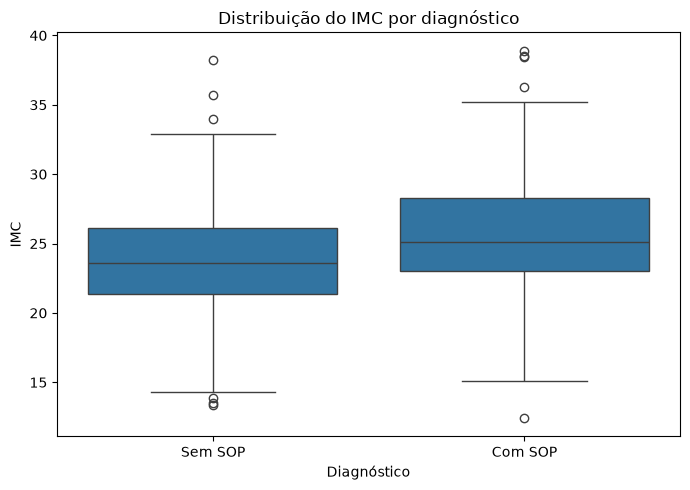

In [129]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=data,
    x="PCOS (Y/N)",
    y="BMI"
)

plt.xticks(
    [0, 1],
    ["Sem SOP", "Com SOP"]
)

plt.title("Distribuição do IMC por diagnóstico")
plt.xlabel("Diagnóstico")
plt.ylabel("IMC")

plt.tight_layout()
plt.show()

Diferentemente das características analisadas anteriormente, a distribuição do IMC apresenta grande sobreposição entre pacientes com e sem SOP. O grupo diagnosticado apresenta uma mediana de IMC ligeiramente superior, porém a diferença entre as distribuições é relativamente pequena. Esse comportamento é coerente com a correlação de Pearson encontrada anteriormente (\(r\approx0,199\)), indicando uma associação linear positiva, porém fraca, entre IMC e presença de SOP. É interessante observar que, embora o ganho de peso tenha apresentado associação mais forte com SOP, o valor absoluto do IMC isoladamente possui uma relação consideravelmente menor com o diagnóstico.

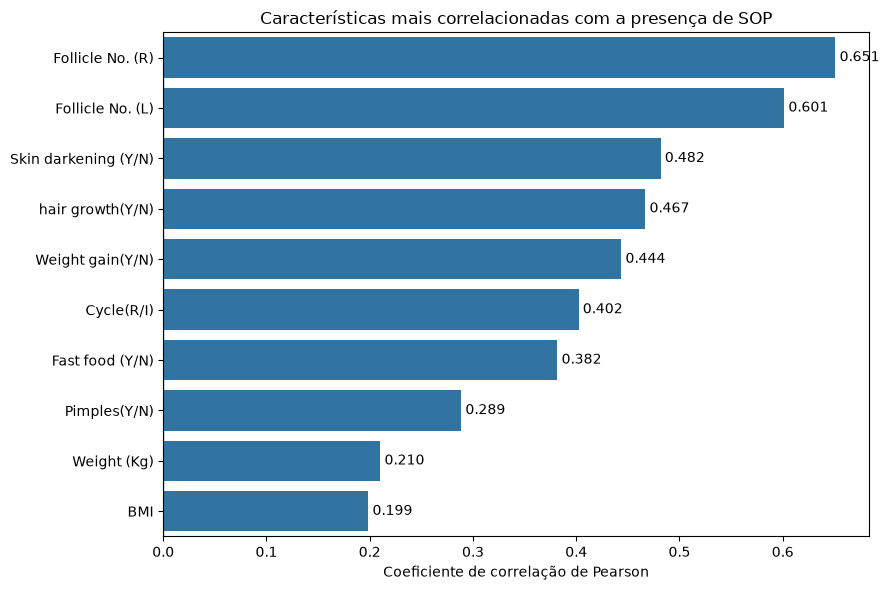

In [130]:
correlations = (
    data.corr(numeric_only=True)["PCOS (Y/N)"]
    .drop("PCOS (Y/N)")
    .sort_values(key=abs, ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=correlations.values,
    y=correlations.index
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.title("Características mais correlacionadas com a presença de SOP")
plt.xlabel("Coeficiente de correlação de Pearson")
plt.ylabel("")

plt.axvline(
    x=0,
    linewidth=1
)

plt.tight_layout()
plt.show()

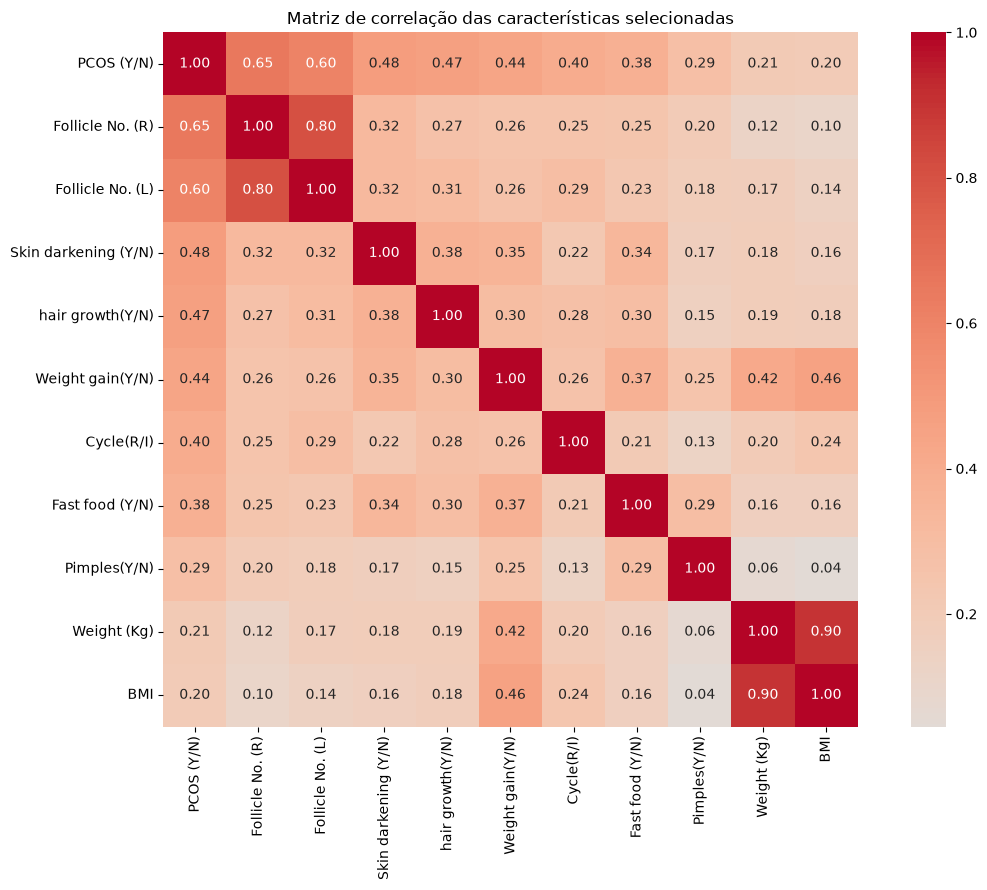

In [131]:
features = [
    "PCOS (Y/N)",
    "Follicle No. (R)",
    "Follicle No. (L)",
    "Skin darkening (Y/N)",
    "hair growth(Y/N)",
    "Weight gain(Y/N)",
    "Cycle(R/I)",
    "Fast food (Y/N)",
    "Pimples(Y/N)",
    "Weight (Kg)",
    "BMI"
]

corr = data[features].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Matriz de correlação das características selecionadas"
)

plt.tight_layout()
plt.show()

O ranking das correlações reforça os padrões observados nas análises anteriores. O número de folículos apresenta as maiores associações lineares com a presença de SOP, tanto no ovário direito (\(r=0,651\)) quanto no esquerdo (\(r=0,601\)). Em seguida aparecem manifestações clínicas como escurecimento da pele, crescimento de pelos e ganho de peso. A regularidade do ciclo também apresenta associação relevante com a variável-alvo. Por outro lado, peso corporal e IMC apresentam correlações consideravelmente menores. Esses resultados não determinam quais características serão necessariamente mais importantes para os modelos de classificação, pois a correlação de Pearson analisa relações lineares entre pares de variáveis.

A matriz de correlação permite observar simultaneamente as relações entre as características selecionadas. Além das associações com a presença de SOP já discutidas, destacam-se relações fortes entre algumas das próprias variáveis explicativas. O número de folículos dos ovários esquerdo e direito apresenta correlação de aproximadamente 0,80, enquanto peso e IMC apresentam correlação de aproximadamente 0,90. Essas relações indicam que algumas características carregam informações semelhantes ou relacionadas entre si, aspecto que deverá ser considerado durante a construção e interpretação dos modelos. A matriz também reforça que nenhuma característica analisada apresenta, isoladamente, uma associação perfeita com o diagnóstico, justificando a utilização de modelos capazes de considerar múltiplas características simultaneamente.

## Selecionando as Características (Features) para o processo de treino

O processo de análise exploratória dos dados nos permitiu identificar quais características apresentam associações mais relevantes com o nosso alvo (target), que representa o diagnóstico ou não de SOP. A partir desses resultados, é possível reduzir o conjunto de características utilizado durante o treinamento.

A primeira característica que optamos por não utilizar é o consumo de fast food. Apesar da associação observada durante a EDA, esse dado está relacionado principalmente a um aspecto comportamental da paciente, enquanto optamos por priorizar características clínicas e físicas.

A segunda característica removida é o peso (Weight (Kg)). Durante a análise de correlação observamos uma forte relação entre peso e IMC (\(r\approx0,90\)). Como essas características carregam informações relacionadas, optamos por manter apenas o IMC, evitando a presença de informações excessivamente redundantes no conjunto selecionado.

Dessa forma, foram selecionadas oito características para a etapa inicial de treinamento dos modelos.


In [132]:
trainingFeatures = [
    "Follicle No. (R)",
    "Follicle No. (L)",
    "Skin darkening (Y/N)",
    "hair growth(Y/N)",
    "Weight gain(Y/N)",
    "Cycle(R/I)",
    "Pimples(Y/N)",
    "BMI"
]

target = "PCOS (Y/N)"

X = data[trainingFeatures].copy()
y = data[target].copy()

print(X.columns)
print(X.shape)
print(y.shape)

Index(['Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)',
       'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Pimples(Y/N)',
       'BMI'],
      dtype='str')
(539, 8)
(539,)



Para a separação dos dados de teste e treino utilizamos a operação padrão de separar 80% dos dados para treino e 20% para teste, conforme apresentado e aulas e fortemente recomendado pela literatura. Como a análise exploratória mostrou uma diferença na proporção das classes, foi utilizada uma divisão estratificada, preservando aproximadamente a proporção de pacientes com e sem SOP em ambos os conjuntos.

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Treino:")
print(y_train.value_counts(normalize=True))

print("\nTeste:")
print(y_test.value_counts(normalize=True))

Treino:
PCOS (Y/N)
0    0.672854
1    0.327146
Name: proportion, dtype: float64

Teste:
PCOS (Y/N)
0    0.675926
1    0.324074
Name: proportion, dtype: float64


Para comparar abordagens diferentes de classificação foram selecionados inicialmente dois modelos: Regressão Logística e Árvore de Decisão.

A Regressão Logística fornece uma abordagem linear para o problema, enquanto a Árvore de Decisão permite representar relações e divisões não lineares entre as características.

Agora que temos os dados para treino e teste do modelo de regressão logísticoa, precisamos ajustar as escalas dos dados, já que temos dados binários e dados descritvos, para ajustar tudo isso vamos utilizar os pipelines do scikitlearn, buscando uma maior assertividade, já que a padronização dos valores beneficia os processos de regressão logística.

In [134]:
logistic_model = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(random_state=42,max_iter=1000))])
logistic_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Follicle No. (R)','Follicle No. (L)','Skin darkening (Y/N)',..., 'Cycle(R/I)','Pimples(Y/N)','BMI']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [135]:
y_pred_logistic = logistic_model.predict(X_test)
y_pred_logistic

array([0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0])

Juntamente com o modelo de regressão logística vamos treinar um modelo de decisionTree, para que possamos o desempenho obtido pelos dois modelos. No caso do modelo de Decision Tree, não precisamos fazer o ajuste de escala dos valores, devido a natureza de operação da DecisionTree

In [136]:
tree_model = DecisionTreeClassifier(random_state=42,max_depth=5)
tree_model.fit(X_train,y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [137]:
y_pred_tree = tree_model.predict(X_test)
y_pred_tree

array([0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

Tendo ambos os modelos treinados, podemos agora avaliar as métricas de resultado apresentada para cada um dos modelos, utilizando métricas provenientes de funções do scikitlearn, para facilitar os processos defini uma função para apresentar as métricas de forma padronizada, economizando linhas de código

In [138]:
def plotConfusionMatrix(name, y_true, y_pred):
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["Sem SOP", "Com SOP"],
        cmap="Blues",
        values_format="d"
    )

    plt.title(f"Matriz de Confusão - {name}")
    plt.xlabel("Valor Predito")
    plt.ylabel("Valor Real")
    plt.show()

def evaluateModel(name, y_true, y_pred):
    print(f"\n{name}")
    print("-" * 40)

    print(
        f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}"
    )

    print(
        f"Precision: {precision_score(y_true, y_pred):.3f}"
    )

    print(
        f"Recall:    {recall_score(y_true, y_pred):.3f}"
    )

    print(
        f"F1-score:  {f1_score(y_true, y_pred):.3f}"
    )

    print("\nMatriz de confusão:")
    plotConfusionMatrix(name, y_true, y_pred)
    


Regressão Logística
----------------------------------------
Accuracy:  0.907
Precision: 0.857
Recall:    0.857
F1-score:  0.857

Matriz de confusão:


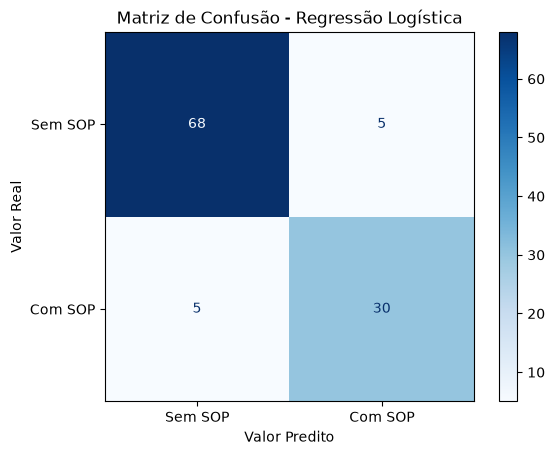

In [139]:
evaluateModel(
    "Regressão Logística",
    y_test,
    y_pred_logistic
)


Árvore de Decisão
----------------------------------------
Accuracy:  0.861
Precision: 0.763
Recall:    0.829
F1-score:  0.795

Matriz de confusão:


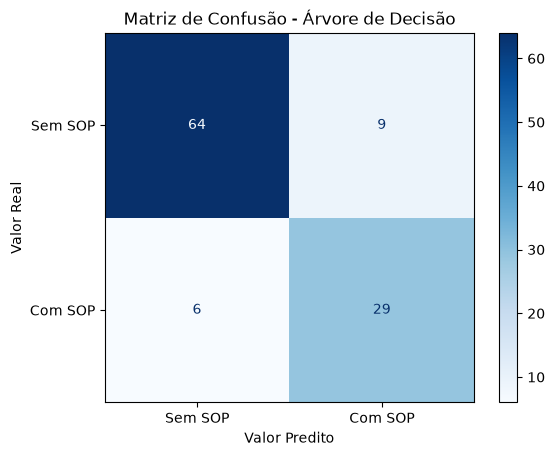

In [140]:
evaluateModel(
    "Árvore de Decisão",
    y_test,
    y_pred_tree
)

### Análise dos resultados dos modelos

Como preconiza a a literatura e conforme apresentado durante as aulas, após o treinamento, os modelos foram avaliados utilizando o conjunto de teste, composto por dados que não foram utilizados durante o processo de treinamento. Para a comparação foram consideradas as métricas de acurácia, precisão, recall e F1-score.

A Regressão Logística apresentou os melhores resultados entre os dois modelos avaliados, obtendo acurácia de aproximadamente 90,7%, enquanto a Árvore de Decisão apresentou aproximadamente 86,1%. A Regressão Logística também apresentou resultados superiores de precisão, recall e F1-score.

Considerando especificamente o recall da classe positiva, a Regressão Logística identificou aproximadamente 85,7% das pacientes que efetivamente apresentavam SOP, enquanto a Árvore de Decisão identificou aproximadamente 82,9%. O que a princípio pode parecer uma diferença desprezíel, mas levando em consideração o contexto do modelo e sua aplicação na área da saúde, o mínimo 'deslize ou falha' pode representar um risco direto à suade das pacientes.

A análise da matriz de confusão mostra que a Regressão Logística classificou incorretamente 5 pacientes com SOP como não possuindo a síndrome, enquanto a Árvore de Decisão apresentou 6 falsos negativos. Esse tipo de erro merece atenção especial considerando a proposta do sistema como ferramenta de apoio para identificação de pacientes com possível risco de SOP.

É sempre importante frisar que, apesar dos resultados obtidos, o modelo nunca deve ser interpretado como substituto do diagnóstico médico, e sim como uma ferramenta de apoio capaz de identificar padrões nos dados analisados.

### Interpretabilidade dos modelos e conclusão

#### 1 - Regressão Logística

In [141]:
logistic_regression = logistic_model.named_steps["model"]
logistic_importance = pd.Series(logistic_regression.coef_[0],index=X_train.columns).sort_values()
logistic_importance

BMI                    -0.097315
Pimples(Y/N)            0.389067
Follicle No. (L)        0.604941
hair growth(Y/N)        0.635958
Cycle(R/I)              0.677243
Weight gain(Y/N)        0.698305
Skin darkening (Y/N)    0.733812
Follicle No. (R)        1.739365
dtype: float64

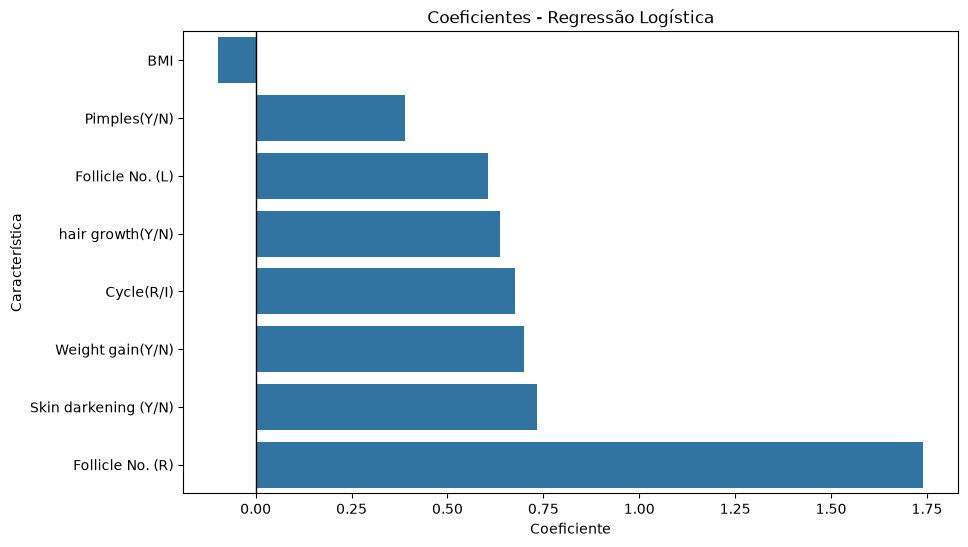

In [142]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=logistic_importance.values,
    y=logistic_importance.index
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Coeficientes - Regressão Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Característica")
plt.show()

#### 2 - Árvore de decisão

In [143]:
tree_importance = pd.Series(
    tree_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

tree_importance

Follicle No. (R)        0.604621
hair growth(Y/N)        0.097434
Skin darkening (Y/N)    0.092572
Follicle No. (L)        0.089052
BMI                     0.042122
Cycle(R/I)              0.037806
Weight gain(Y/N)        0.033395
Pimples(Y/N)            0.002997
dtype: float64

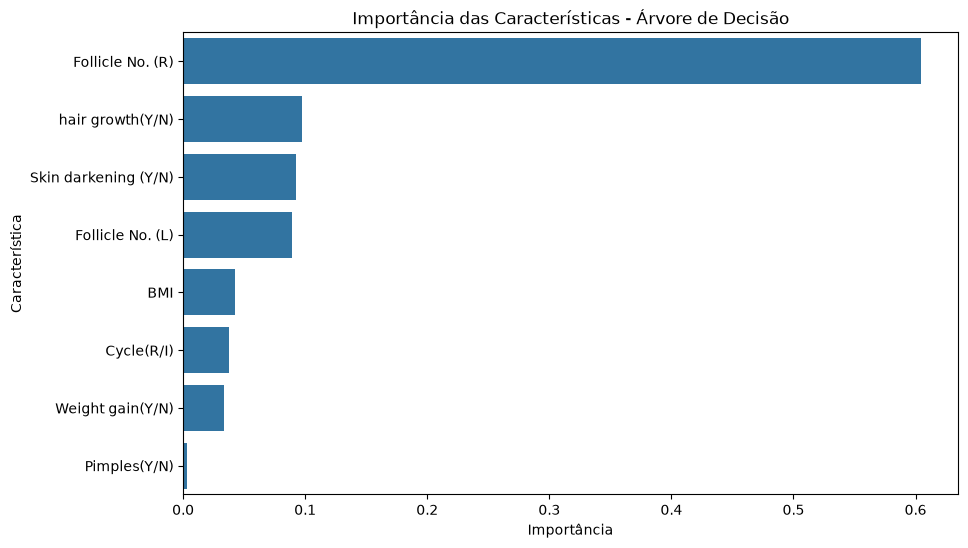

In [144]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=tree_importance.values,
    y=tree_importance.index
)

plt.title("Importância das Características - Árvore de Decisão")
plt.xlabel("Importância")
plt.ylabel("Característica")
plt.show()

Os resultados obtidos durante a análise de interpretabilidade apresentam uma relação interessante com os resultados encontrados anteriormente durante a análise exploratória dos dados. O número de folículos no ovário direito, que apresentou a maior correlação com a presença de SOP durante a EDA, também foi a característica de maior destaque nos dois modelos avaliados.

Na Regressão Logística, o número de folículos no ovário direito apresentou o maior coeficiente positivo entre as características utilizadas. Outras características, como escurecimento da pele, ganho de peso, regularidade do ciclo e crescimento de pelos, também apresentaram contribuições positivas relevantes para a classificação.

Na Árvore de Decisão, o número de folículos no ovário direito apresentou uma importância de aproximadamente 0,60, sendo a característica mais utilizada pelo modelo em seu processo de decisão. Entretanto, esse valor não deve ser interpretado como uma contribuição percentual para o diagnóstico, mas como uma medida da importância da característica dentro da estrutura da árvore treinada.

Também é possível observar algumas diferenças entre os resultados da análise exploratória e a importância atribuída pelos modelos. O número de folículos no ovário esquerdo, por exemplo, apresentou uma das maiores correlações individuais com a presença de SOP, mas recebeu menor destaque nos modelos. Uma possível explicação é a forte correlação observada entre o número de folículos dos dois ovários, indicando que essas características carregam informações relacionadas.

Esses resultados também reforçam a diferença entre correlação e importância para um modelo. Enquanto a correlação avalia a associação entre duas variáveis isoladamente, os modelos consideram simultaneamente diferentes características para realizar a classificação.

Durante o processo de análise exploratória foi possível identificar diferentes características associadas à presença de SOP. Entre elas, o número de folículos nos ovários, que apresentou as maiores correlações com a variável-alvo, seguido por características como escurecimento da pele, crescimento de pelos, ganho de peso e irregularidade do ciclo menstrual. As análises também demonstraram que nenhuma dessas características, quando observada isoladamente, é suficiente para determinar a presença da síndrome, reforçando a necessidade de considerar diferentes informações em conjunto, reforçando ainda que não estão diretamente ligadas a causa, sendo apenas informações associadas à condição.

Para a classificação os modelos utilizados foram, Regressão Logística e Árvore de Decisão. Sendo a Regressão Logística o modelo que apresentou o melhor desempenho no conjunto de teste, atingindo aproximadamente 90,7% de acurácia e 85,7% de recall para a classe positiva. A Árvore de Decisão apresentou aproximadamente 86,1% de acurácia e 82,9% de recall. Além da acurácia, foi dada atenção especial ao recall, considerando que falsos negativos representam pacientes que possuem SOP, mas que não foram devidamente identificadas pelo modelo.

A análise da importância das características também apresentou resultados coerentes com parte dos padrões observados durante a análise exploratória. O número de folículos no ovário direito, que apresentou a maior correlação individual com a presença de SOP, também apresentou grande influência nos dois modelos. Ao mesmo tempo, foram observadas diferenças entre correlação e importância para os modelos, demonstrando que uma característica associada individualmente à variável-alvo não necessariamente terá a mesma relevância quando analisada em conjunto com as demais.

Apesar dos resultados obtidos, algumas limitações devem ser consideradas. O conjunto utilizado possui uma quantidade relativamente pequena de registros e representa uma população específica, portanto os resultados obtidos neste experimento não permitem afirmar que os modelos apresentariam o mesmo desempenho quando aplicados a outras populações ou contextos. Além disso, os modelos foram construídos utilizando apenas um subconjunto das características disponíveis, selecionado a partir da análise exploratória realizada neste trabalho.

Por fim, principalmente considerando o contexto da área da saúde, os resultados apresentados jamais devem ser interpretados como uma proposta de substituição do diagnóstico realizado por profissionais especializados. Uma solução baseada em Inteligência Artificial pode atuar efetivamente como ferramenta de apoio, auxiliando na identificação de padrões e indicando casos que mereçam maior atenção, porém a interpretação dessas informações e a decisão final devem sempre permanecer sob responsabilidade dos profissionais da área, sendo esses indispensáveis para o correto tratamento de condições médicas